<a href="https://colab.research.google.com/github/vg137/bert-dissection/blob/main/step_3_positional_and_type_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now, we have seen that a trained embedding layer gives some semantic value to every token. But languages have more structure. The meaning of a sentence not only depends on the meaning of it's words but also on the order in which they appear. We need a mechanism to take into account the position of the token in a sentence.

The first thing which comes to mind is to use actual position indices directly. But this is problematic because of the following reasons:
* **Non-linear sensitivity**: Depending on the task, it might be more acceptable to misplace tokens in some parts of the sentences compared to some other parts of the sentences. To capture this, we can try to find an embedding (or actually *learn* it) in which the position indices in the sensitive parts of the sentence get farther apart than those in the non-sensitive parts.
* **Non-linear similarity**: There are long-range correlations in the sentences of a language. For example, the first few positions usually dictate how the sentence end. These positions usually pretty similar and have nouns and pronouns in them. The middle parts of a sentence differs from the start and the end by having verbs generally. An embedding can bring the first few and the last few positions closer to each other than they are to the middle parts.
* **Not continuous**: Transformer architecture (like most neural networks) works with tensors with real number entries and not just integers

So, we want to map the positions to some real vector space s.t. the map satisfies some nice properties. This is called **positional encoding (or positional embedding)**. A trivial approach is one-hot encoding. It is even worse than using the position indices because all the embedded positions are equidistant from every other position making the concept of distance in the embedding space useless.

We want embeddings which don't have the above shortcomings and even offer other benefits. To do this, we consider embeddings which map the $n$<sup>th</sup> position of a sequence to the $n$<sup>th</sup> row of some embedding matrix. If the maximum sequence length is $L_\mathrm{max}$ and the embedding dimension is $N_\mathrm{embed}$, then the embedding matrix has dimensions $L_\mathrm{max} \times N_\mathrm{embed}$. Note that we want to add the position embedding vector to the word embedding vector for every token. This is why the embedding dimension here is the same as that for the word embedding.

Let's see how to fill in the embedding matrix to make the embedding useful.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer

### BERT positional encoding

Unlike the sinusoidal positional encoding (which was used in the original paper on transformers), BERT uses a learned positional embedding. This type of embedding is better adapted to the training data.

In [ ]:
model = AutoModel.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
bert_pe_layer = model.embeddings.position_embeddings

In [ ]:
bert_pe_matrix = bert_pe_layer.weight

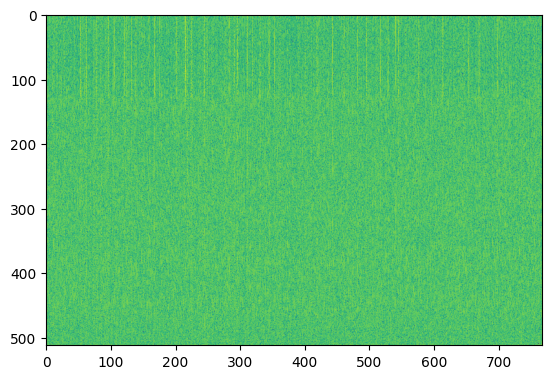

In [ ]:
plt.imshow(np.log(np.abs(bert_pe_matrix.detach().numpy())))

In [ ]:
bert_row_distance_arr = np.zeros([bert_pe_matrix.shape[0], bert_pe_matrix.shape[0]])
for i in range(bert_pe_matrix.shape[0]):
    for j in range(0, bert_pe_matrix.shape[0]):
        bert_row_distance_arr[i, j] = torch.linalg.norm(bert_pe_matrix[i] - bert_pe_matrix[j]).detach()

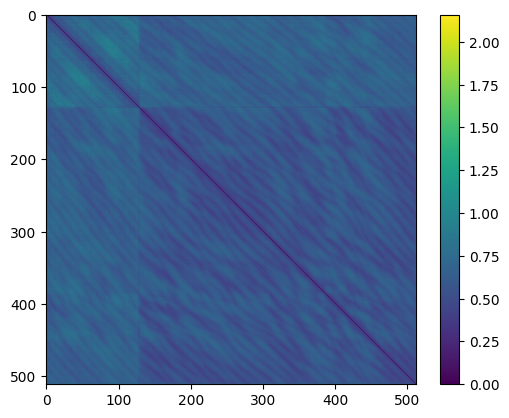

In [ ]:
# plt.imshow(np.log(np.abs(bert_row_distance_arr)))
plt.imshow(bert_row_distance_arr)
plt.colorbar()

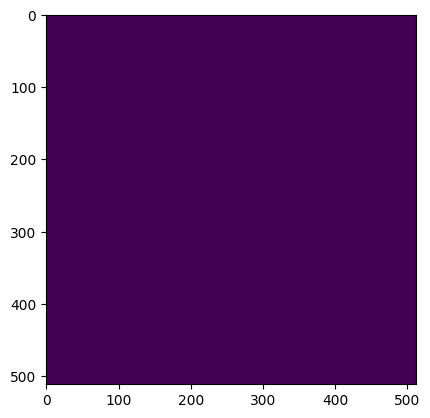

In [ ]:
plt.imshow(bert_row_distance_arr - bert_row_distance_arr.T)

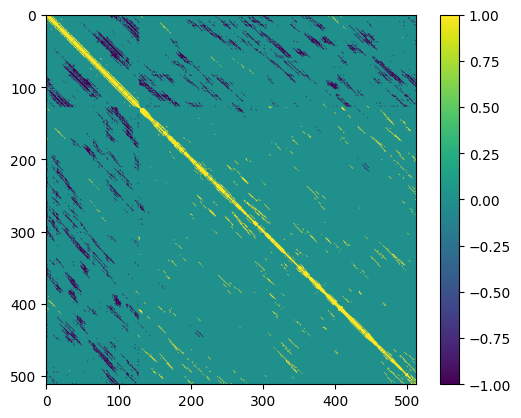

In [ ]:
bert_row_distance_arr_torch = torch.from_numpy(bert_row_distance_arr)

k = 10
D = bert_row_distance_arr_torch

truncated_matrix = torch.zeros_like(D)

for i in range(D.shape[0]):
    max_values, max_indices = torch.topk(D[i], k, largest=True)
    min_values, min_indices = torch.topk(D[i], k, largest=False)

    truncated_matrix[i, max_indices] = -1
    truncated_matrix[i, min_indices] = 1

# Symmetrize
close = truncated_matrix == 1
far = truncated_matrix == -1

close_sym = close | close.T
far_sym = far | far.T

truncated_matrix_sym = torch.zeros_like(truncated_matrix)

# Choose conflict priority:
# far first, then close means close wins if both occur
truncated_matrix_sym[far_sym] = -1
truncated_matrix_sym[close_sym] = 1

truncated_matrix = truncated_matrix_sym
plt.imshow(truncated_matrix)
plt.colorbar()

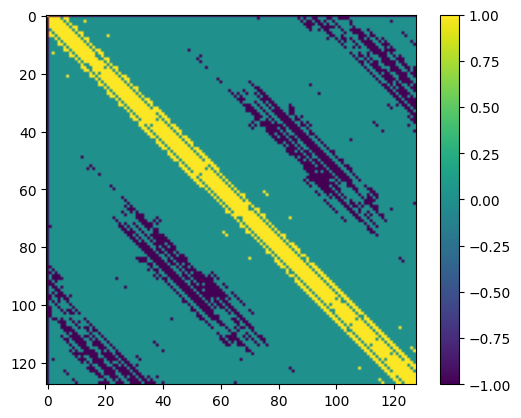

In [ ]:
plt.imshow(truncated_matrix[:128, :128])
plt.colorbar()

### BERT type/segment embedding

Due to the nature of the downstream tasks (like answering questions) that BERT was originally designed for, every token is also embedded in another space which captures the type of sentence which the token belongs to. So, every token has a token type which is either 0 or 1 depending on the sentence. Again, these are discrete numbers and we want to map it some vector in $\mathbb{R}^{N_\mathrm{embed}}$. Note that, again, we want to add the type embedding vector to the word and the position embedding vectors. So, all these embeddings are of the same size ($N_\mathrm{embed} = 768$).

The type embedding vectors are also learned during pre-training.

In [ ]:
type_embedding_matrix = model.embeddings.token_type_embeddings.weight.detach().numpy()
print(type_embedding_matrix)

[[ 0.00043164  0.01098826  0.00370439 ... -0.00661185 -0.00336983
  -0.00864201]
 [ 0.00111319 -0.00299169 -0.00317028 ...  0.00474542 -0.0052443
  -0.01121742]]


### Sinusoidal positional encoding

One standard approach is the sinusoidal positional encoding in which the positional embedding matrix (PEM) is
\begin{equation}
M^{(\mathrm{PE})}_{l n} =
\begin{cases}
\sin \Big(K^{-n/L_\mathrm{max}} l \Big) & \mathrm{even} \ n \\
\cos \Big(K^{-(n-1)/L_\mathrm{max}} l \Big) & \mathrm{odd} \ n
\end{cases}
\end{equation}
where $l = 0, 1, \dots, L_\mathrm{max}$, $n = 0, 1, \dots, N_\mathrm{pe}$, and $K$ is some large number (usually $\sim 10^5$). To see why this is useful, note that
\begin{equation}
\mathrm{row}_l(M^{(\mathrm{PE})}) \cdot \mathrm{row}_{l'}(M^{(\mathrm{PE})}) = \sum_{n = 0}^{N_\mathrm{pe}/2 - 1} {\cos\Big(K^{-n/L_\mathrm{max}} (l - l')\Big)}
\end{equation}
The squared distance between the embedding vectors for these positions is then
\begin{align}
||\mathrm{row}_l(M^{(\mathrm{PE})}) - \mathrm{row}_{l'}(M^{(\mathrm{PE})})||^2 &= \mathrm{row}_l(M^{(\mathrm{PE})}) \cdot \mathrm{row}_l(M^{(\mathrm{PE})}) + \mathrm{row}_{l'}(M^{(\mathrm{PE})}) \cdot \mathrm{row}_{l'}(M^{(\mathrm{PE})}) \\
&\hspace{7cm}- 2 \ \mathrm{row}_l(M^{(\mathrm{PE})}) \cdot \mathrm{row}_{l'}(M^{(\mathrm{PE})}) \\
&= N_\mathrm{pe} - 2 \sum_{n = 0}^{N_\mathrm{pe}/2 - 1} {\cos\Big(K^{-n/L_\mathrm{max}} (l - l')\Big)}
\end{align}
We note that both the dot product and the distance in the embedding space have translational invariance and are not directional i.e. they are functions of $|l - l'|$. So, neighbouring positions will have the same distance in embedding space no matter which part of the sentence they are from. <u> The actual reason behind using these functions will become clear when we will discuss self-attention.</u>

Also, the reason for using wavelengths which form a geometric series (instead of an algebraic one) is to capture larger and larger scales with fewer coefficients.

Let's plot this distance.

In [ ]:
def generate_sinu_pe_matrix(L_max, N_pe, K=10**5):

    pe_matrix = np.zeros([L_max, N_pe])

    for n in range(L_max):
        for l in range(N_pe):
            if l % 2 == 0:
                pe_matrix[n, l] = np.sin(K**(-l/L_max) * n)
            else:
                pe_matrix[n, l] = np.cos(K**(-(l-1)/L_max) * n)

    return pe_matrix

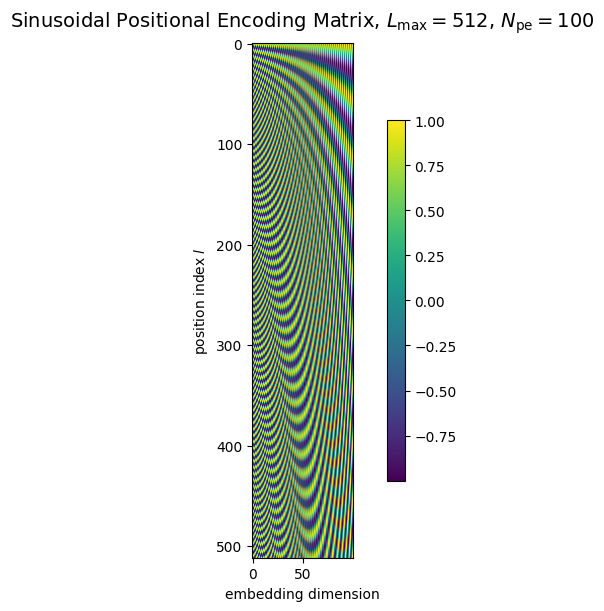

In [ ]:
L_max = 512
N_pe = 100

pe_matrix = generate_sinu_pe_matrix(L_max, N_pe)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax.imshow(pe_matrix)
ax.set_xlabel("embedding dimension")
ax.set_ylabel(r"position index $l$")


ax.set_title(
    rf"Sinusoidal Positional Encoding Matrix, $L_{{\max}}={L_max}$, $N_{{\mathrm{{pe}}}}={N_pe}$",
    fontsize=14,
    pad=12,
)
plt.colorbar(im, ax=ax, shrink=0.7)
plt.show()

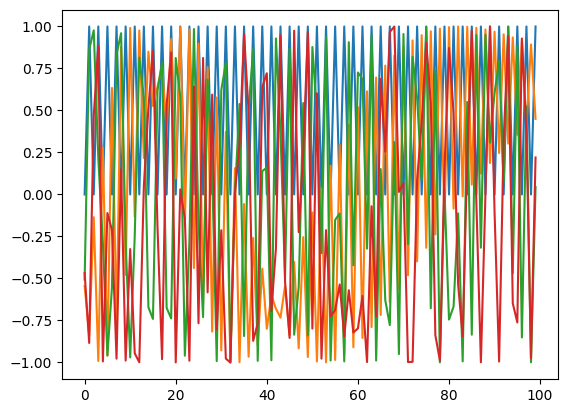

In [ ]:
plt.plot(pe_matrix[[0, 10, 100, 500], :100].transpose())

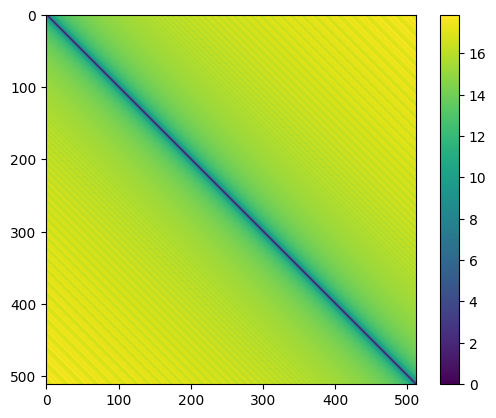

In [ ]:
sinu_row_distance_arr = np.zeros([L_max, L_max])
for i in range(L_max):
    for j in range(0, L_max):
        sinu_row_distance_arr[i, j] = np.linalg.norm(pe_matrix[i] - pe_matrix[j])

plt.imshow(sinu_row_distance_arr)
plt.colorbar()

We see an overall power-law increase in the distance in embedding space